# Evaluation Metrics

After we are done with the finetuning, how can we formalize the improvement of the fine tuned model over the pretrained model we started with? We can use evaluation metrics to assess the performance of our model and compare with other models out in the world. In the case where the output is already known (deterministic), we can assess the simple metrics like accuracy. But, when the model response is non-deterministic as with the LLM, language model based evaluation is much more challenging.

For example: \\
Example1: Mike really loves drinking tea. \\
Example2: Mike adores sipping tea.

Example3: Mike does not drink coffee. \\
Example4: Mike does drink coffee.

There is only one word difference in the word however the meaning is completely different.

ROUGE and BLEU Score are two widely used evaluation metrics for different tasks.

**Why the evaluations of the model is required?**
1. Performance assessment
2. Model Comparison
3. Bias detection and mitigation
4. User satisfaction and trust

### ROUGE


ROUGE stands for Recall Oriented Understudy for Gisting Evaluation. This metrics is mainly used for text summarization tasks. It compares a summary to one or more human generated reference summaries. ROUGE scores for different tasks are not comparable to each other. Summarization ROUGE score is incomparable to NER ROUGE score.

Example: (using the unigram) \\
Reference (Human): It is cold outside. \\
Generated Output1: It is very cold outside. \\
Generated Output2: It is not cold outside. \\

$$ ROUGE-1 \; Recall = \frac{unigram \; matches}{unigrams \; in \; reference} = \frac{4}{4} = 1.0$$

$$ ROUGE-1 \; Precision = \frac{unigram \; matches}{unigrams \; in \; output} = \frac{4}{5} = 0.8 $$

$$ ROUGE-1 \; F1 = 2 \; \frac{precision \; * \; recall}{precision \; * \; recall} = 2 \; \frac{0.8}{1.8} = 0.89 $$

This ROUGE-1 can be deceptive. The model might generate content that is subjectively poor but score good. Like in the above example, two generated different outputs have different meanings but the same score. This can get slightly better with bigrams. Working with a pair of words means acknowledging the order of words in a sentence.

Example: (using the bigram) \\
Reference (Human): It is cold outside. \\
using bigram: It is, is cold, cold outside.  \\
Generated Output1: It is very cold outside. \\
using bigram: It is, very cold, cold outside.

$$ ROUGE-2 \; Recall = \frac{unigram \; matches}{unigrams \; in \; reference} = \frac{2}{3} = 0.67 $$

$$ ROUGE-2 \; Precision = \frac{unigram \; matches}{unigrams \; in \; output} = \frac{2}{4} = 0.5 $$

$$ ROUGE-2 \; F1 = 2 \; \frac{precision \; * \; recall}{precision \; * \; recall} = 2 \; \frac{0.335}{1.17} = 0.57 $$


We can see that the score decreases. There are chances that with longer sentences that bigrams don’t match and score are even lower. So, rather than increasing the ROUGE number to big (2,3,...), we can use ROUGE-L (Longest Common Subsequence)

**Rouge-L** measures longest matching sequences of words. It doesn't compare n-grams, but instead treats each summary as a sequence of words and looks for longest Common Subsequence (LCS). The subsequence is of the same relative order but not necessarily contiguous.


Example: (using the unigram) \\
Reference (Human): It is cold outside. \\
Generated Output1: It is very cold outside. \\
Here, the Longest Common Subsequence (LCS) is 2. i.e. It is, cold outside

$$ ROUGE-L \; Recall = \frac{LCS(Gen, \; Ref)}{unigrams \; in \; reference} = \frac{2}{4} = 0.5 $$

$$ ROUGE-L \; Precision = \frac{LCS(Gen, \; Ref)}{unigrams \; in \; output} = \frac{2}{5} = 0.4 $$

$$ ROUGE-L \; F1 = 2 \; \frac{precision \; * \; recall}{precision \; * \; recall} = 2 \; \frac{0.2}{0.9} = 0.44 $$

### BLEU Score


BLEU stands for Bilingual Evaluation Understudy. It is used for analyzing the quality of machine translated text with the human translated text. The score is calculated using average precision over multiple n-gram sizes.  This checks how many n-grams in the machine generated translation match with those in the reference translation.

BLEU scores range from 0 to 1, with higher scores indicating better performance.


We can use the different libraries to calculate the BLEU score, among which one of them is HuggingFace. https://huggingface.co/spaces/evaluate-metric/bleu

Examples: \\
Reference (human): \\
I am very happy to say that I am drinking a warm cup of tea.

Generated output: \\
I am very happy that I am drinking a cup of tea. BLEU = 0.495 \\
I am very happy that I am drinking a warm cup of tea. BLEU = 0.730 \\
I am very happy to say that I am drinking a warm tea. BLEU = 0.798 \\

Both ROUGE, BLEU score are realtively simpler metrics and are relatively low cost to calculate. But, we should not use them alone to evaluate the final performance of final LLM. Use them only for diagnostic evaluation of the performance in summaization and translation tasks respectively.

For overall evaluation of our model's performance however, we will have to look at one of the evaluation benchmarks that have been developed by researchers.


### Human Evaluation

In Human evaluation, the human evaluators assess the quality of the language model's output. These evaluators rate the generated responses based on different criteria including, relevance, fluency, coherence, overall quality of specific tasks.

This approach offers subjective feedback on the model's performance. The valuation can be subjective and prone to bias because of varying opinoins. This approach is time-consuming and expensive especially for large-scale evaluations.

### Benchmarks

In order to measure and compare LLM more holistically, we can make use of pre-existing dataset and associated benchmarks that have been established by LLM researchers specifically for this purpose. Selecting the right evaluation dataset is crucial, so that we can accurately assess LLM performance and understand its true capabilities.

Curated datasets are prepared for each benchmark task, including training, validation, and test sets. These datasets should be large enough to capture the variations in language use, domain-specific nuances, and potential biases.

Evaluation Benchmarks: \\
- GLUE
- SuperGLUE
- HELM
- MMLU (Massive Multitask Lanuage Understanding)
- Big-Bench


Benchmarking steps for a better evaluation of LLM performance:
1. Benchmark Selection
2. Dataset Preparation
3. Model Training and Fine Tuning
4. Model Evaluation
5. Comparative Analysis


The factors that should be considered while evaluating the performance of the models are:
- Knowledge and Capability Evaluation
  - Question Answering
  - Knowledge Completion
  - Reasoning
    - Commonsense Reasoning
    - Logical Reasoning
    - Multi-hop reasoning
    - Mathematical Reasoning
- Alignment Evaluation
  - Ethics and Morality
  - Bias
  - Toxicity
  - Truthfulness
- Safety Evaluation
  - Robustness Evaluation
  - Risk Evaluation
- Specialized LLMs Evaluation
  - Biology and Medicine
  - Education
  - Legislation
  - Computer Science
  - Finance


Source (Survey Paper): https://arxiv.org/abs/2310.19736


**GLUE**

GLUE stands for General Language Understanding Evaluation.
A benchmark of nine sentence- or sentence-pair language understanding tasks built on established existing datasets and selected to cover a diverse range of dataset sizes, text genres, and degrees of difficulty. It is mainly the collection of NLP tasks like sentiment analysis and Question Answering.

Paper: https://openreview.net/pdf?id=rJ4km2R5t7

**SuperGLUE**

SuperGLUE is a successor to GLUE to reduce limitations in GLUE. It includes the tasks that are not included in GLUE and some are the challenging versions of the tasks. It includes tasks like multisentence reasoning and reading comprehension. As model gets larger, their performance against benchmarks start to match human ability on specific tasks.

Paper: https://w4ngatang.github.io/static/papers/superglue.pdf


**Benchmarks for Massive Models**

**MMLU (Massive Multitask Language Understanding)**

It is designed specificaly for modern LLMs. To perform well, model must possess extensive world knowledge and problem solving ability. Models are tested on elementary mathematics, US history, Computer Science, Law and more. These task are beyond basic langage understanding.

Paper: https://arxiv.org/abs/2009.03300

**Big Bench**

Big Bench consisits of 204 tasks reanging through (linguistics, maths, common sense, biology, physics, software development, etc.). They are of different sizes to keep costs achievable as running these large benchmarks can incur large inference costs.
- Big-Bench Hard
- Big-Bench
- Lite

https://github.com/google/BIG-bench


**HELM**

HELM stands for Holistic Evaluation of Language Models. It aims to improve the transparency of models and to offer guidance on which model performs well for specific tasks. It takes multi-metric approach measuring seven metrics: accuracy, calibration, robustness, fairness, bias, toxicity, efficiency.

### ELO Rating

Elo rating is the rating system initially created to rank chess players around the world. Players start with a rating between 1000 Elo (beginner) and 2800 Elo or higher (pros). When a player wins a match, their rating goes up based on their opponent’s Elo rating.

If player A has a rating of Ra and player B a rating of Rb, the exact formula (using the logistic curve with base 10) for the probability of player A winning is

$$ E_A = \frac{1}{1 + 10^{\frac{(R_B - R_A)}{400}}}$$

The ratings of players can be linearly updated after each battle. Suppose player A (with Rating Ra) was expected to score Ea points but actucally scored Sa points. The formula for updating that player's rating is

$$ R'_A = R_A + K . (S_A - E_A) $$

If a player wins then the score $S_A$ is 1, if loses its 0 and if plays a draw then its 0.5. Whenever the player does better than expected $E_A$, their rating increases. If you beat a very low rated player, you will have fewer increases in points than that when you beat a player with a high or similar rating.

This is the same way we can rank LLMs. We can rank multiple models at the same time, based on their performance in head-to-head matchups.

For the data collection part, Each of the models in comparison will generate their own version of the response based on the same prompt. Humans rank the output of the models such that the model is hidden to the human and only the outputs from each model are shown.

All models start with a base level of 1500 Elo. They all begin with an equal footing, ensuring a fair comparison. As we evaluate and rank the outputs, the system will update the Elo ratings for each model based on their performance.

Sources: https://lmsys.org/blog/2023-05-03-arena/


### Guardrails


Human input plays a key role in making large language models safer and more reliable. One of the main ways in which human input is valuable is in the establishment and enforcement of guardrails.

LLM are hard to control. They suffer from hallucination and are stochastic (for same input the output are not always the same). And, to control the model via training and finetuning, it is quite expensive and time consuming. So, we use Guradrails to control the output of LLM.

Funtions of Guardrails:
- Enforces structure and type guarantees (e.g. JSON)
- Does pydantic-style validation of LLM outputs
- Takes corrective actions (e.g. reasking LLM) when validation fails


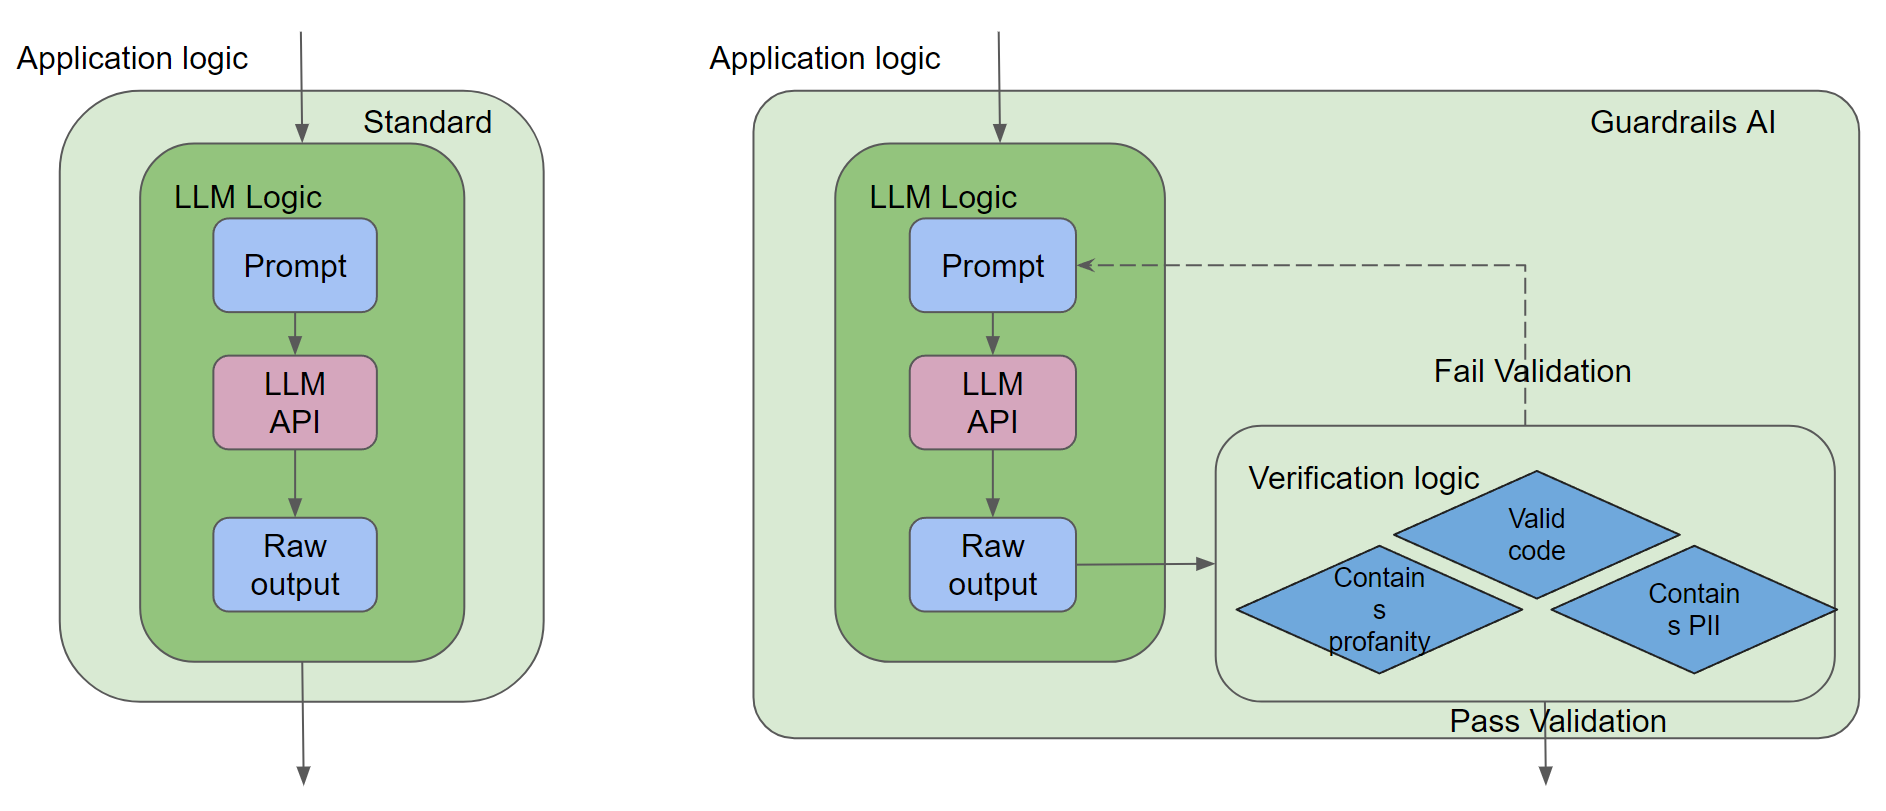

After we get the raw output from LLM, we pass it to the verification logic that contains small independent programs that encapsulates what correctness means for our application. This could check Personal Identifying Information (PII), contains profanity, valid execuatable code, etc.

If the verification passes, then send the output of LLM to next step of our application. But if the verification logic fails then, we have few different options to handle them, one of which is to construct a new prompt again. The prompt is changed such that this time the prompt also contains what went wrong in the previous ouput.

Guardrails AI is an opensource library that offers
- Framework for creating custom validators
- Orchestration of prompting → verification → re-prompting
- Library for commonly used validators for multiple use cases
- Specification language for generating structured LLM outputs


Key benefits of guardrails:
- Protect against the misuse of AI technologies
- Promote equality and prevent bias
- Preserve public trust in AI technologies
- Comply with legal and regulatory standards
- Facilitate human oversight in AI systems

Source: https://github.com/guardrails-ai/guardrails